## Source code for generating Fig. 11 in the paper ["STAR-Magic Mutation: Even More Efficient Analog Rotation Gates for Early Fault-Tolerant Quantum Computer"](https://arxiv.org/abs/2603.22891)

In [3]:
import numpy as np

def calc_R_count_for_STAR1(N_T: int, N_range: tuple = (0, 12)) -> int:
    n_r_list = np.logspace(N_range[0], N_range[1], num=1000, base=10, dtype=int)
    p_ph = 1e-3
    for n_r in reversed(n_r_list):
        p_total = (2/15)* (N_T+ 2*n_r) * p_ph
        if p_total < 1:
            return n_r
    return 0



def calc_R_count_for_STAR2(N_T: int, theta=1e-4, N_range: tuple = (0, 12)) -> int:
    n_r_list = np.logspace(N_range[0], N_range[1], num=1000, base=10, dtype=int)
    p_ph = 1e-3
    alpha_RUS = 1.6
    for n_r in reversed(n_r_list):
        p_total = ((2/15)*N_T + alpha_RUS*n_r*theta) * p_ph
        if p_total < 1:
            return n_r
    return 0


def calc_R_count_for_STAR3(N_T: int, theta=1e-4, N_range: tuple = (0, 12)) -> int:
    n_r_list = np.logspace(N_range[0], N_range[1], num=1000, base=10, dtype=int)
    p_ph = 1e-3
    p_m = 2e-9
    alpha_RUS = 0.1
    for n_r in reversed(n_r_list):
        p_total = p_m*N_T + n_r * alpha_RUS * theta * p_ph
        if p_total < 1:
            return n_r
    return 0


def calc_R_count_for_FTQC(N_T: int, N_range: tuple = (0, 12)) -> int:
    n_r_list = np.logspace(N_range[0], N_range[1], num=1000, base=10, dtype=int)
    p_m = 2e-9
    delta = p_m
    N_sys = 3 * np.log2(1/delta)
    for n_r in reversed(n_r_list):
        p_total = (N_T + 1.6*n_r*N_sys) * p_m + n_r * delta
        if p_total < 1:
            return n_r
    return 0


[np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993109181), np.int64(993

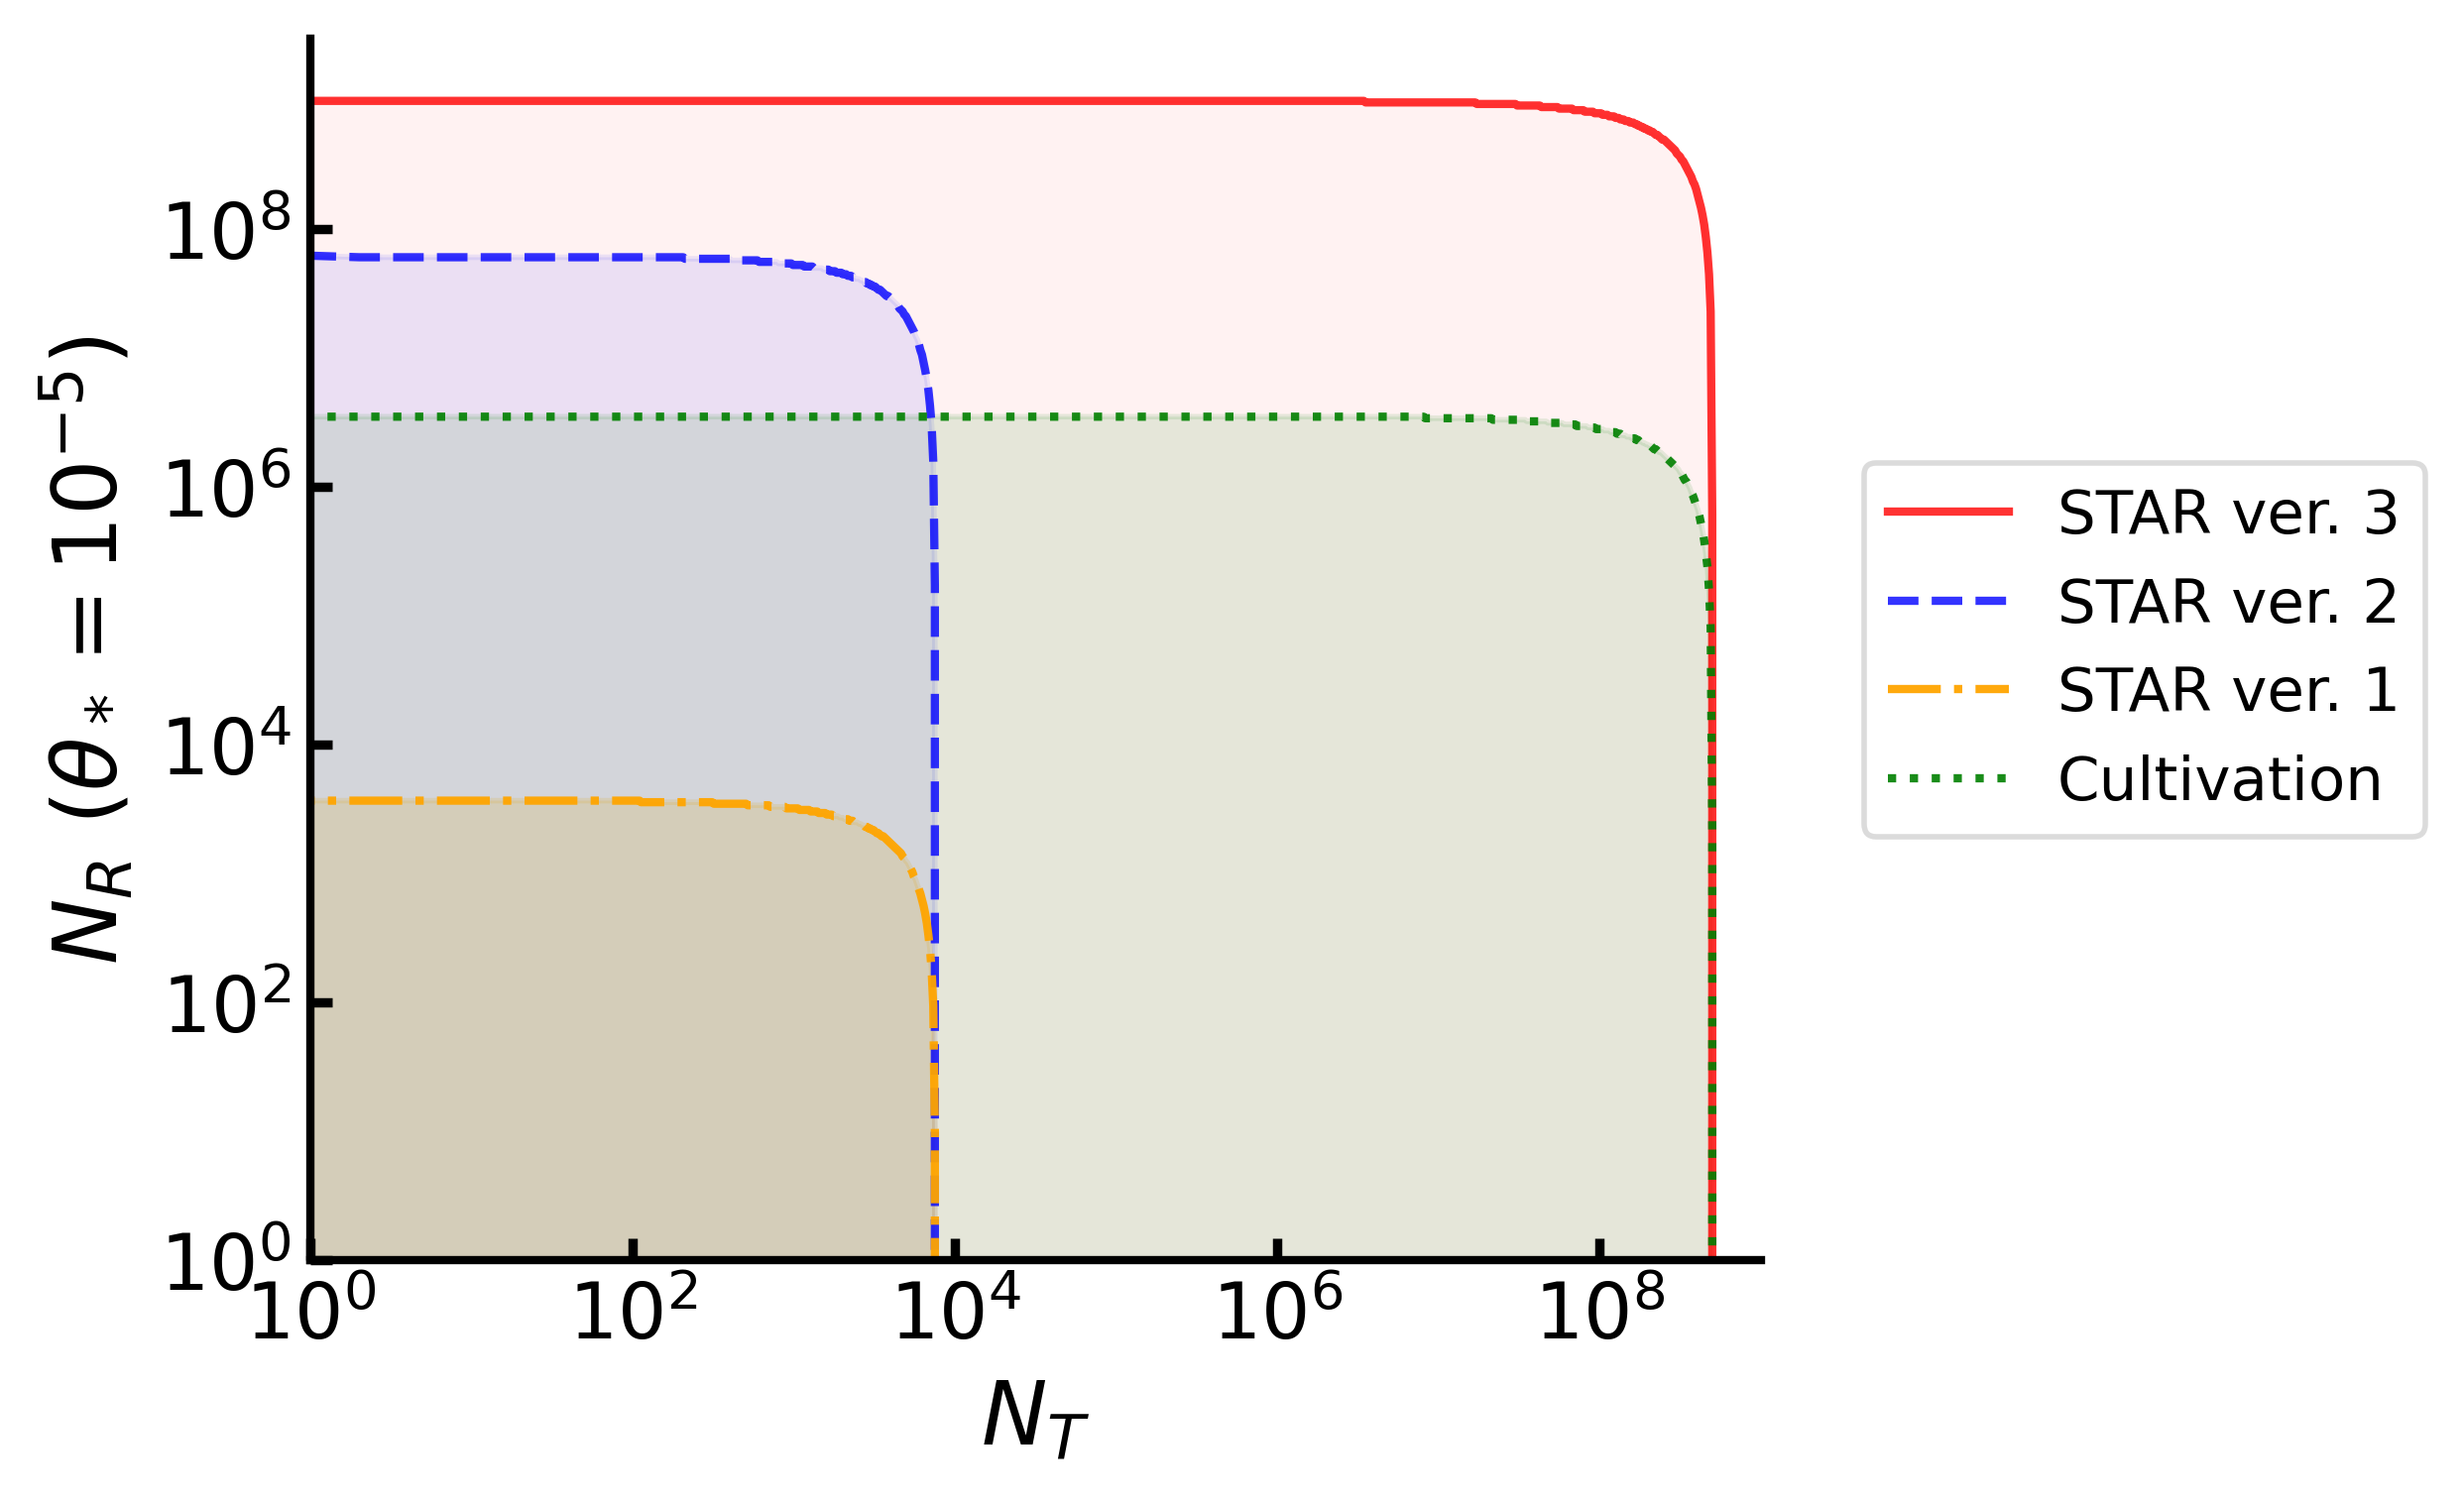

In [4]:
import matplotlib.pyplot as plt
from starsim.util.plot_parameters import set_parameter_for_plot

set_parameter_for_plot(3)

theta=1e-5
N_T_list = [0] + list(np.logspace(0, 10, num=1000, base=10, dtype=int))
R_count_list_for_STAR1 = [calc_R_count_for_STAR1(N_T, N_range=(0,12)) for N_T in N_T_list]
R_count_list_for_STAR2 = [calc_R_count_for_STAR2(N_T, theta=theta, N_range=(0,12)) for N_T in N_T_list]
R_count_list_for_FTQC = [calc_R_count_for_FTQC(N_T, N_range=(0,12)) for N_T in N_T_list]
R_count_list_for_STAR3 = [calc_R_count_for_STAR3(N_T, theta=theta, N_range=(0,12)) for N_T in N_T_list]

print(R_count_list_for_STAR3)
fig, ax = plt.subplots()

# plot the curves for each method
ax.plot(N_T_list, R_count_list_for_STAR3, label='STAR ver. 3', color='red', ls='-', alpha=0.8)
ax.plot(N_T_list, R_count_list_for_STAR2, label='STAR ver. 2', color='blue', ls='--', alpha=0.8)
ax.plot(N_T_list, R_count_list_for_STAR1, label='STAR ver. 1', color='orange', ls='-.', alpha=0.95)
ax.plot(N_T_list, R_count_list_for_FTQC, label='Cultivation', color='green', ls=':', alpha=0.9)


# Draw filled areas between the curves and the x-axis
ax.fill_between(N_T_list, R_count_list_for_STAR3, alpha=0.05, color='red')
ax.fill_between(N_T_list, R_count_list_for_STAR2, alpha=0.08, color='blue')
ax.fill_between(N_T_list, R_count_list_for_STAR1, alpha=0.15, color='orange')
ax.fill_between(N_T_list, R_count_list_for_FTQC, alpha=0.1, color='green')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1, 3e9)
ax.set_xlim(1, 1e9)
ax.set_xlabel(r'$N_T$')
ax.set_ylabel(r'$N_R\ (\theta_*=10^{-5})$')
ax.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')  # Place the legend outside the plot at the center-right
ax.set_aspect(0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#plt.grid(True)
plt.show()